## NB 2

## 1. Setup and load clean data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clean data from NB1
df = pd.read_csv('C:/Projects/11_Financial_AML/data/aml_cleaned.csv')
print(f"Ready to engineer features for {len(df)} transactions.")

Ready to engineer features for 2770409 transactions.


## 2. Feature Engineering

In [3]:
# 1. Balance Error at Origin: Match check on the sender's side
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']

# 2. Balance Error at Desination: Match check on the receiver's side 
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

#3. Hour of Day: Money Laundering often happens in brusts
df['hour'] = df['step'] % 24

print ("New features created : errorBalanceOrig, errorBalanceDest, hour")

New features created : errorBalanceOrig, errorBalanceDest, hour


## 3. Data preprocessing ( preparing for the machine)

In [4]:
# Convert 'type' into numbers (TRANSFER = 1, CASH_OUT = 0)
df = pd.get_dummies(df, columns=['type'], drop_first=True)

# Drop high-cardinality columns (Names/IDs) to prevent overfitting
df_final = df.drop(['nameOrig', 'nameDest', 'step'], axis=1)

display(df_final.head())

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,errorBalanceOrig,errorBalanceDest,hour,type_TRANSFER
0,181.00,181.0,0.0,0.0,0.00,1,0.00,181.0,1,True
1,181.00,181.0,0.0,21182.0,0.00,1,0.00,21363.0,1,False
2,229133.94,15325.0,0.0,5083.0,51513.44,0,213808.94,182703.5,1,False
3,215310.30,705.0,0.0,22425.0,0.00,0,214605.30,237735.3,1,True
4,311685.89,10835.0,0.0,6267.0,2719172.89,0,300850.89,-2401220.0,1,True


## 4. Export Engineered Dataset

In [4]:
# Save the final engineered dataset
df_final.to_csv('C:/Projects/11_Financial_AML/data/aml_engineered.csv', index=False)
print("SUCCESS: aml_engineered.csv saved. Next step: Model Training!")

SUCCESS: aml_engineered.csv saved. Next step: Model Training!


## 5. Feature Selection and train- test Split

In [5]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df_final.drop(['isFraud'], axis=1)
y = df_final['isFraud']

# Stratified split: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Fraud case in Test set: {y_test.sum()}")

Training set size: 2216327
Fraud case in Test set: 1643


## Train XG Boost

In [6]:
from xgboost import XGBClassifier

# Calculate the ratio for scale_pos_weight
# count(negative) / count(positive)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# Initialize the model
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio, # This is the magic for the imbalance!
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
    )

# Fit the model
model.fit(X_train, y_train)
print("Model training complete")

Model training complete


## Evaluation

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    552439
           1       0.86      1.00      0.92      1643

    accuracy                           1.00    554082
   macro avg       0.93      1.00      0.96    554082
weighted avg       1.00      1.00      1.00    554082



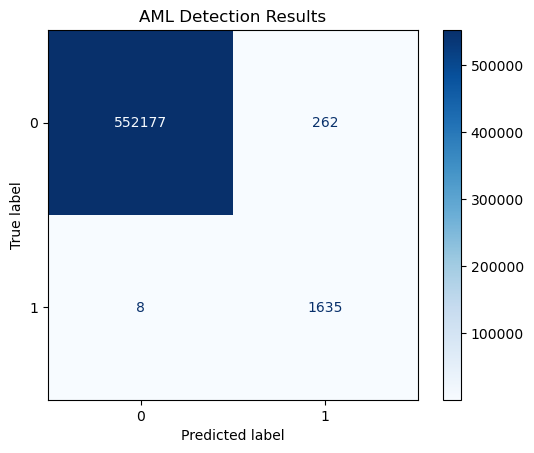

In [7]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Make prediction
y_pred = model.predict(X_test)

# Display results
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues")
plt.title('AML Detection Results')
plt.show()

In [8]:
# Check which feature the model relied on most
importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

errorBalanceOrig    0.760271
newbalanceOrig      0.202906
amount              0.025421
oldbalanceOrg       0.004525
oldbalanceDest      0.002599
newbalanceDest      0.001391
errorBalanceDest    0.001258
hour                0.001209
type_TRANSFER       0.000419
dtype: float32


## Feature Importance

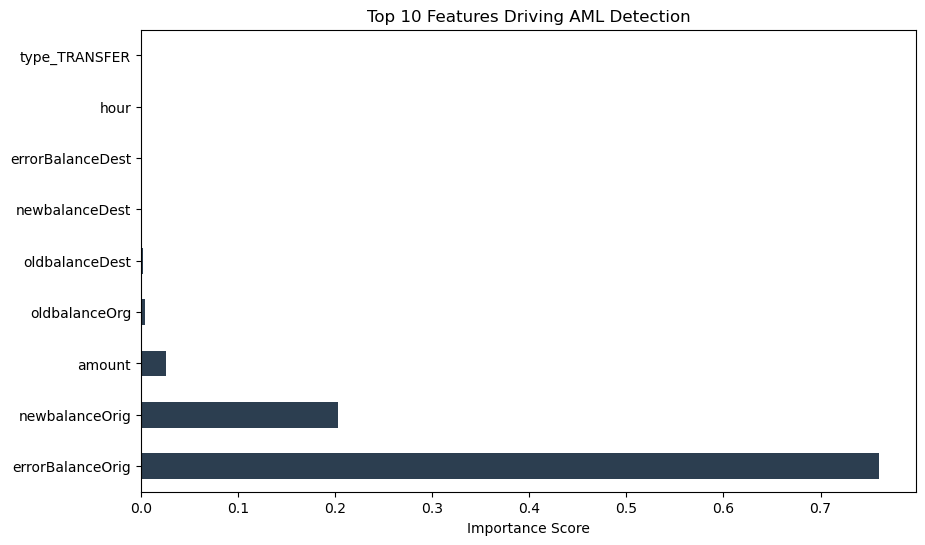

In [9]:
# Plotting feature importance
plt.figure(figsize=(10,6))
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color="#2C3E50")
plt.title("Top 10 Features Driving AML Detection")
plt.xlabel('Importance Score')
plt.show()

## Save the model

In [12]:
import joblib
# Save the model and the columns 
joblib.dump(model, 'C:/Projects/11_Financial_AML/model/aml_xgb_model.pkl')
joblib.dump(X.columns.to_list(),  'C:/Projects/11_Financial_AML/model/model_columns.pkl')

print("Model successfully serialized to /models folder.")

Model successfully serialized to /models folder.
